In [13]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/custom.css
/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/outputs/features/feature_names.csv
/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/outputs/features/feature_names.pkl
/kaggle/input/notebooks/hafsaferdousi5/02-2model-catboost/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/02-2model-catboost/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/02-2model-catboost/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/02-2model-catboost/custom.css
/kaggle/input/notebooks/hafsaferdousi5/02-2model-catboost/outputs/results/catb_classification_report.csv
/kaggle/input/notebooks/hafsaferdousi5/02-2model-catboost/outputs/results/catb_confusion_matrix.png
/kaggle/input

In [14]:
import joblib

feature_names = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/outputs/features/feature_names.pkl"
)

print(type(feature_names))
print("Number of features:", len(feature_names))
print(feature_names[:10])

<class 'list'>
Number of features: 77
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


In [2]:
!pip install -q shap lime

In [3]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap

from lime.lime_tabular import LimeTabularExplainer

from sklearn.metrics import classification_report

print("SHAP:", shap.__version__)

SHAP: 0.51.0


In [4]:
os.makedirs("outputs/explainability/shap", exist_ok=True)
os.makedirs("outputs/explainability/lime", exist_ok=True)

print("Output directories created.")

Output directories created.


In [5]:
data = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl"
)

X_train, X_test, y_train, y_test = data

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5055991, 77)
X_test : (1263998, 77)
y_train: (5055991,)
y_test : (1263998,)


In [17]:
X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

print("X_train:", X_train_df.shape)
print("X_test :", X_test_df.shape)

X_train: (5055991, 77)
X_test : (1263998, 77)


In [18]:
print(X_train_df.columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

In [20]:
rf = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/outputs/models/random_forest.pkl"
)

xgb = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/outputs/models/XGboost.pkl"
)

lgb = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm/outputs/models/lightgbm_leaves31.pkl"
)

cat = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/02-2model-catboost/outputs/models/catboost.pkl"
)
stacking = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/ensemble/outputs/models/stacking_ensemble.pkl"
)

print("All five models loaded successfully.")

All five models loaded successfully.


In [21]:
print("Random Forest :", type(rf))
print("XGBoost       :", type(xgb))
print("LightGBM      :", type(lgb))
print("CatBoost      :", type(cat))
print("Stacking      :",type(stacking))

Random Forest : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
XGBoost       : <class 'xgboost.sklearn.XGBClassifier'>
LightGBM      : <class 'lightgbm.sklearn.LGBMClassifier'>
CatBoost      : <class 'catboost.core.CatBoostClassifier'>
Stacking      : <class 'dict'>


In [25]:
SHAP_SAMPLE_SIZE = 2000

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(X_test_df),
    size=min(SHAP_SAMPLE_SIZE, len(X_test_df)),
    replace=False
)

X_shap = X_test_df.iloc[sample_idx].copy()

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (2000, 77)


In [26]:
import shap

print("Calculating CatBoost SHAP...")

cat_explainer = shap.TreeExplainer(cat)

cat_shap_values = cat_explainer.shap_values(
    X_shap
)

print("SHAP completed.")

Calculating CatBoost SHAP...
SHAP completed.


In [27]:
print(type(cat_shap_values))
print(np.asarray(cat_shap_values).shape)

<class 'numpy.ndarray'>
(2000, 77, 15)


In [28]:
print(len(feature_names))
print(np.asarray(cat_shap_values).shape)

77
(2000, 77, 15)


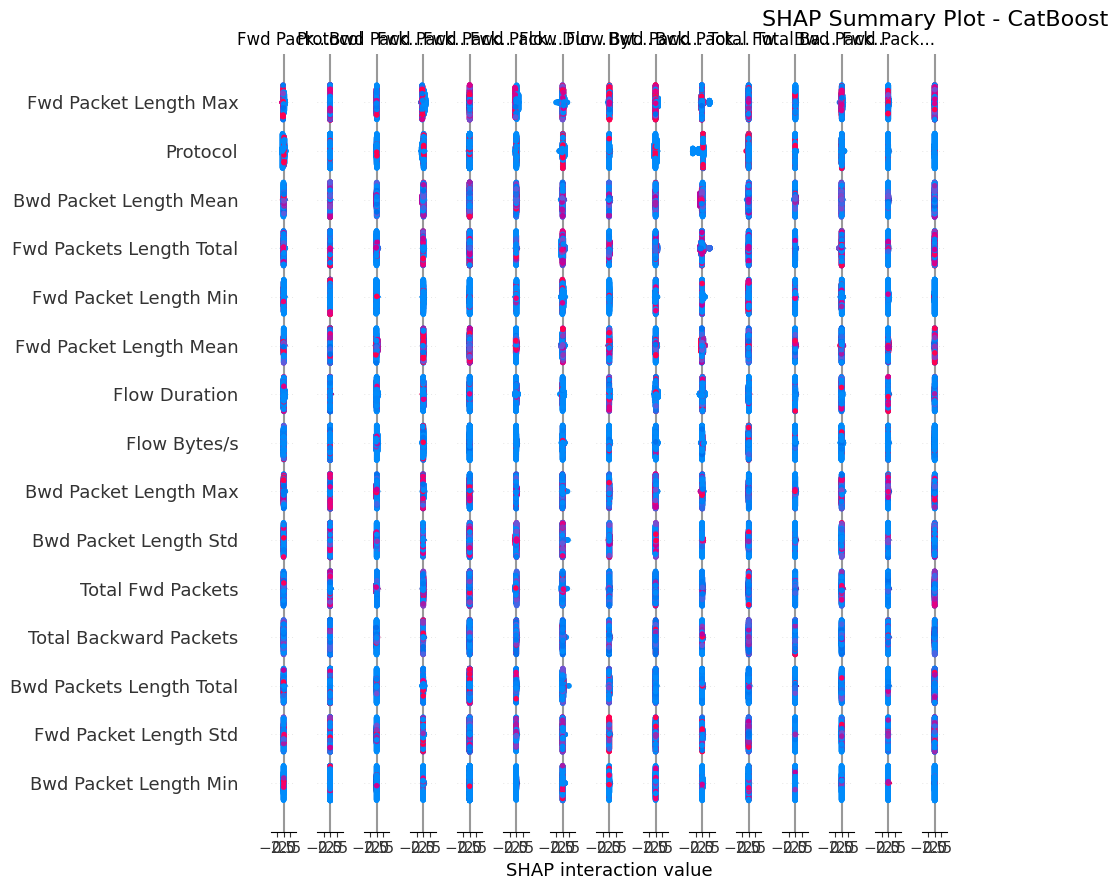

In [31]:


shap.summary_plot(
    cat_shap_values,
    X_shap,
    max_display=20,
    show=False
)

fig = plt.gcf()


fig.set_size_inches(12, 9)

plt.title(
    "SHAP Summary Plot - CatBoost",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    "outputs/explainability/shap/catboost_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

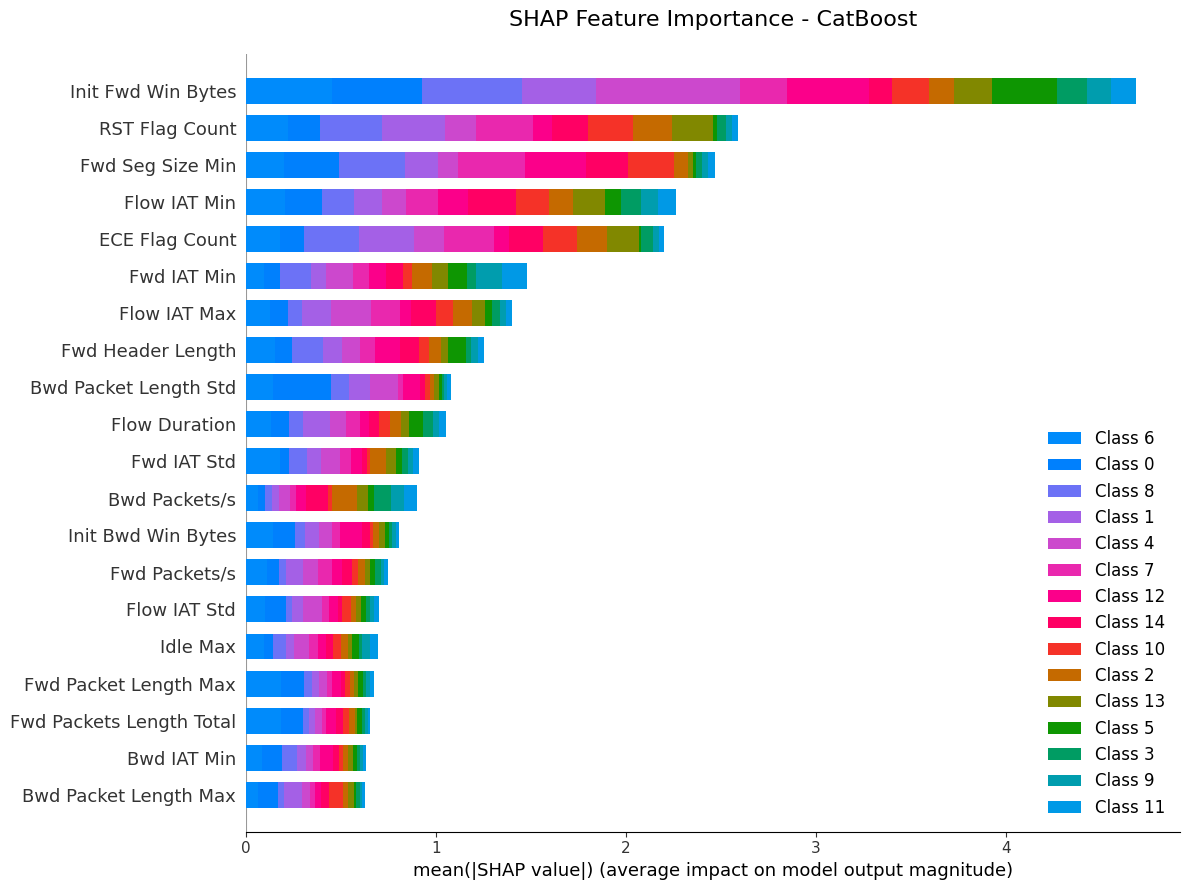

In [32]:
shap.summary_plot(
    cat_shap_values,
    X_shap,
    plot_type="bar",
    max_display=20,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(12, 9)

plt.title(
    "SHAP Feature Importance - CatBoost",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    "outputs/explainability/shap/catboost_shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()




In [33]:
print("X_shap:", X_shap.shape)
print("SHAP:", np.asarray(cat_shap_values).shape)

X_shap: (2000, 77)
SHAP: (2000, 77, 15)


In [34]:
shap_array = np.asarray(cat_shap_values)

print(shap_array.shape)

if shap_array.ndim != 3:
    raise ValueError(
        f"Expected multiclass SHAP values with 3 dimensions, got {shap_array.shape}"
    )

# Mean absolute SHAP across samples and classes
global_importance = np.mean(
    np.abs(shap_array),
    axis=(0, 2)
)

print("Global importance shape:", global_importance.shape)

(2000, 77, 15)
Global importance shape: (77,)


In [35]:
cat_global_shap = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": global_importance
})

cat_global_shap = cat_global_shap.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

cat_global_shap.head(20)

,Feature,Mean_Absolute_SHAP
0,Init Fwd Win Bytes,0.312164
1,RST Flag Count,0.172527
2,Fwd Seg Size Min,0.164445
3,Flow IAT Min,0.150844
4,ECE Flag Count,0.146805
5,Fwd IAT Min,0.098790
6,Flow IAT Max,0.093374
7,Fwd Header Length,0.083562
8,Bwd Packet Length Std,0.071828
9,Flow Duration,0.070136


In [36]:
cat_global_shap.to_csv(
    "outputs/explainability/shap/catboost_global_shap_importance.csv",
    index=False
)

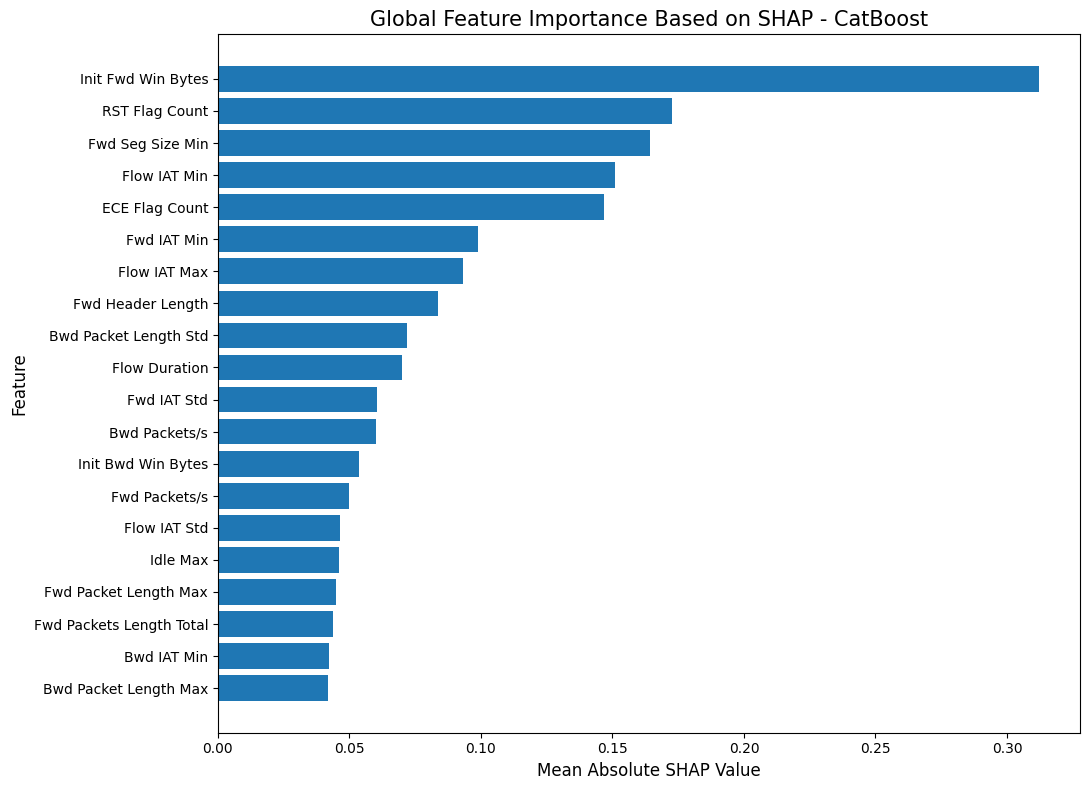

In [37]:
top20 = cat_global_shap.head(20).sort_values(
    "Mean_Absolute_SHAP",
    ascending=True
)

plt.figure(figsize=(11, 8))

plt.barh(
    top20["Feature"],
    top20["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    "Global Feature Importance Based on SHAP - CatBoost",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "outputs/explainability/shap/catboost_global_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [38]:
class_index = 0

class_shap = shap_array[:, :, class_index]

print("Class SHAP shape:", class_shap.shape)

Class SHAP shape: (2000, 77)


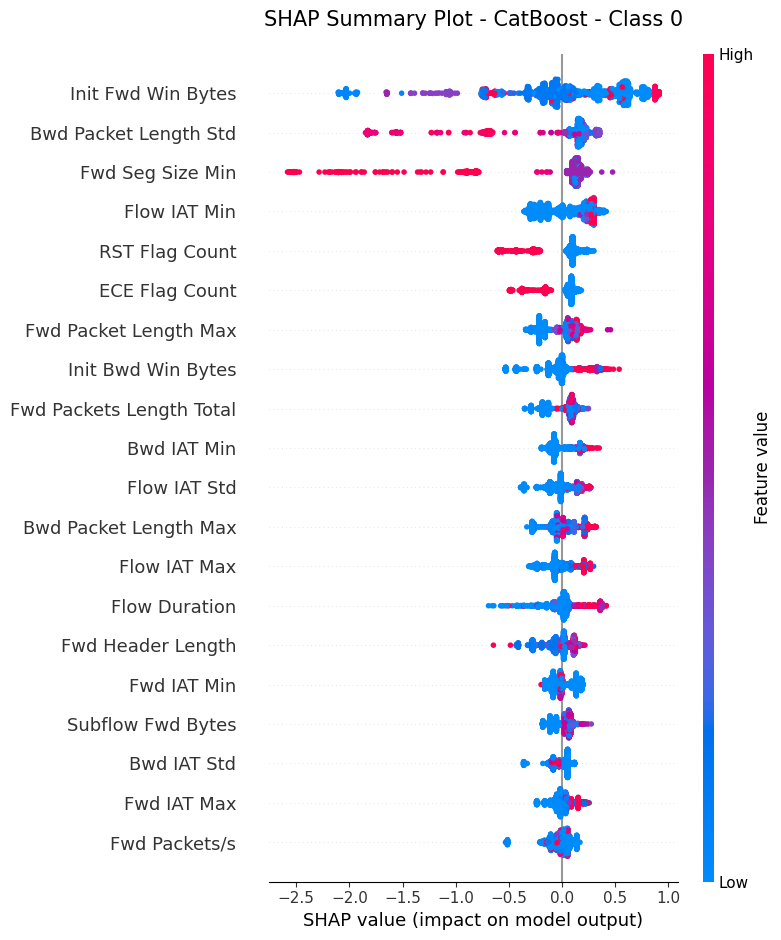

In [39]:
shap.summary_plot(
    class_shap,
    X_shap,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot - CatBoost - Class 0",
    fontsize=15,
    pad=20
)

plt.tight_layout()

plt.savefig(
    "outputs/explainability/shap/catboost_class0_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()